# Model Fitting Workflow

Use this notebook to orchestrate a single model fit, simulate from the fitted parameters, and generate benchmark diagnostics.

In [1]:
%load_ext autoreload
%autoreload 2

# import jax
# jax.config.update("jax_disable_jit", True)

import json
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.fitting import ScipyDE as fitting_method
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
)
from jaxcmr.math import cosine_similarity_matrix
from jaxcmr.simulation import (
    simulate_h5_from_h5,
)
from jaxcmr.simulation import (
    simulate_study_free_recall_and_forced_stop as simulate_trial_fn,
)
from jaxcmr.summarize import summarize_parameters
from jaxcmr.transform_likelihood import (
    ExcludeTerminationLikelihoodFnGenerator as loss_fn_generator,
)

warnings.filterwarnings("ignore")

In [2]:
# Data parameters
base_data_tag = "HealeyKahana2014"
data_tag = "HealeyKahana2014"
data_path = "data/HealeyKahana2014.h5"
embedding_path = "data/peers-all-mpnet-base-v2.npy"
trial_query = "data['listtype'] == -1"
target_directory = "results/"

# Run configuration
base_run_tag = "fixed_term"
experiment_count = 50
max_subjects = 0
seed = 0

# Flow toggles
allow_repeated_recalls = False
filter_repeated_recalls = True
handle_elis = False
redo_fits = False
redo_sims = True
redo_figures = True

# Model configuration
model_name = "WeirdCMRNoStop"
model_factory_path = "jaxcmr.models.weird_cmr_no_stop.BaseCMRFactory"

# fitting hyperparameters
relative_tolerance = 0.001
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 3

# parameter bounds
parameters = {
    "fixed": {
    },
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    },
}

comparison_analysis_paths = [
    "jaxcmr.analyses.distcrp.plot_dist_crp",
    "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve",
    "jaxcmr.analyses.nth_item_recall.plot_simple_nth_item_recall_curve",
    "jaxcmr.analyses.termination_probability.plot_termination_probability",
    "jaxcmr.analyses.spc.plot_spc",
    "jaxcmr.analyses.crp.plot_crp",
    "jaxcmr.analyses.pnr.plot_pnr",
]


In [3]:
# derive run tag
run_tag = f"{base_run_tag}_best_of_{best_of}"
if max_subjects:
    run_tag += f"_nsubs_{max_subjects}"

# add subdirectories for each product type: json, figures, h5
product_dirs = {}
for product in ["fits", "figures", "simulations"]:
    product_dir = os.path.join(target_directory, product)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

# load data
data = load_data(os.path.join(find_project_root(), data_path), max_subjects)
trial_mask = generate_trial_mask(data, trial_query)

# load embeddings and compute distance matrix
max_size = np.max(data["pres_itemnos"])
embeddings = np.load(
    os.path.join(find_project_root(), embedding_path)
).astype(np.float32)
connections = cosine_similarity_matrix(embeddings)
distances = 1 - connections

# import model and analyses
comparison_analyses = [import_from_string(path) for path in comparison_analysis_paths]
model_factory = import_from_string(model_factory_path)
BaseCMR = import_from_string(model_factory_path[:model_factory_path.rfind(".")]+".BaseCMR")

# derive list of query parameters from keys of `parameters`
parameters["fixed"]["allow_repeated_recalls"] = allow_repeated_recalls
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )

## Fit Model

In [4]:
# either load or perform model fits
fit_path = os.path.join(product_dirs["fits"], f"{data_tag}_{model_name}_{run_tag}.json")
print(fit_path)

if os.path.exists(fit_path) and not redo_fits:
    with open(fit_path) as f:
        results = json.load(f)
        if "subject" not in results["fits"]:
            results["fits"]["subject"] = results["subject"]

else:
    base_params = parameters["fixed"]
    bounds = parameters["free"]
    fitter = fitting_method(
        data,
        connections,
        base_params,
        model_factory,
        loss_fn_generator,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": False,
            "bounds": bounds,
            "best_of": best_of,
        },
    )

    results = fitter.fit(trial_mask)
    results = dict(results)

    with open(fit_path, "w") as f:
        json.dump(results, f, indent=4)

results["data_query"] = trial_query
results["model"] = model_name
results["name"] = f"{data_tag}_{model_name}_{run_tag}"

with open(fit_path, "w") as f:
    json.dump(results, f, indent=4)

print(
    summarize_parameters([results], query_parameters, include_std=True, include_ci=True)
)

results/fits/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3.json


Subject=244, Fitness=587.5084228515625: 100%|██████████| 126/126 [16:04<00:00,  7.65s/it] 

| Parameter | Statistic | HealeyKahana2014 WeirdCMRNoStop fixed term best of 3 |
|---|---|---|
| fitness | mean | 525.15 +/- 17.15 |
|  | std | 96.90 |
|  | min | 253.08 |
|  | max | 743.77 |
| encoding drift rate | mean | 0.78 +/- 0.03 |
|  | std | 0.15 |
|  | min | 0.15 |
|  | max | 0.99 |
| start drift rate | mean | 0.13 +/- 0.03 |
|  | std | 0.15 |
|  | min | 0.00 |
|  | max | 0.80 |
| recall drift rate | mean | 0.85 +/- 0.02 |
|  | std | 0.12 |
|  | min | 0.52 |
|  | max | 1.00 |
| shared support | mean | 8.27 +/- 1.91 |
|  | std | 10.78 |
|  | min | 0.00 |
|  | max | 80.36 |
| item support | mean | 18.24 +/- 4.20 |
|  | std | 23.72 |
|  | min | 0.00 |
|  | max | 99.14 |
| learning rate | mean | 0.28 +/- 0.04 |
|  | std | 0.23 |
|  | min | 0.00 |
|  | max | 0.96 |
| primacy scale | mean | 16.09 +/- 4.14 |
|  | std | 23.40 |
|  | min | 0.31 |
|  | max | 99.19 |
| primacy decay | mean | 20.01 +/- 5.00 |
|  | std | 28.25 |
|  | min | 0.00 |
|  | max | 98.19 |
| choice sensitivity | m

## Simulate From Fit

In [ ]:
# either load or perform model simulations

sim_path = os.path.join(
    product_dirs["simulations"], f"{data_tag}_{model_name}_{run_tag}.h5"
)
print(sim_path)

with open(fit_path) as f:
    results = json.load(f)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results["subject"]


rng = random.PRNGKey(seed)
rng, rng_iter = random.split(rng)
trial_mask = generate_trial_mask(data, trial_query)
params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore

if os.path.exists(sim_path) and not redo_sims:
    sim = load_data(sim_path)
    print(f"Loaded from {sim_path}")

else:
    sim = simulate_h5_from_h5(
        model_factory=model_factory,
        dataset=data,
        connections=connections,
        parameters=params,
        trial_mask=trial_mask,
        experiment_count=experiment_count,
        rng=rng_iter,
        simulate_trial_fn=simulate_trial_fn,
    )

    save_dict_to_hdf5(sim, sim_path) # type: ignore
    print(f"Saved to {sim_path}")

if filter_repeated_recalls:
    sim["recalls"] = repetition.filter_repeated_recalls(sim["recalls"])


## Figures

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_dist_crp.png)


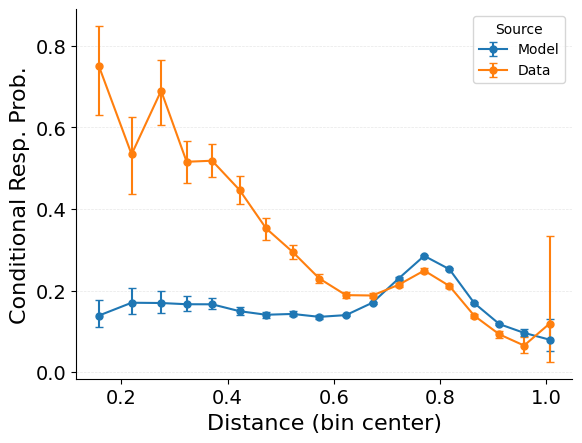

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_conditional_nth_item_recall_curve.png)


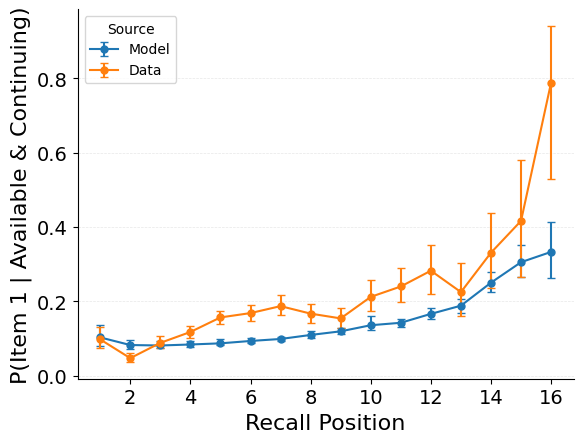

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_simple_nth_item_recall_curve.png)


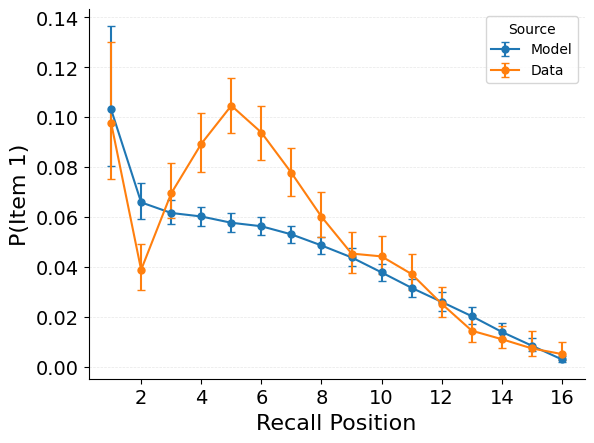

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_termination_probability.png)


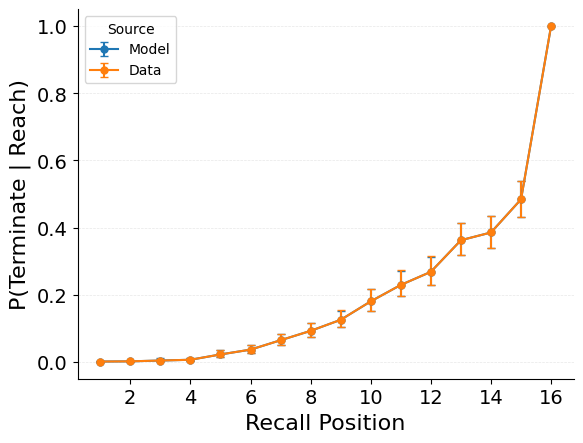

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_spc.png)


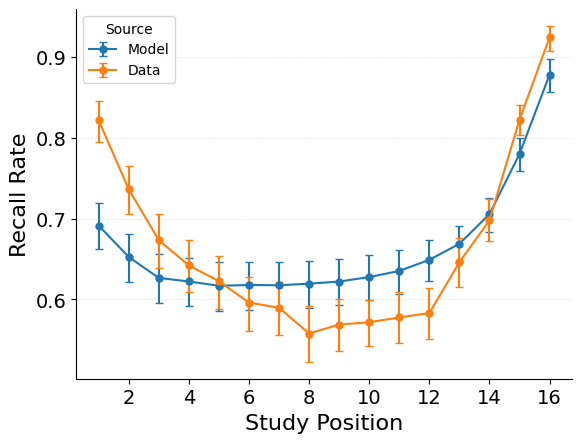

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_crp.png)


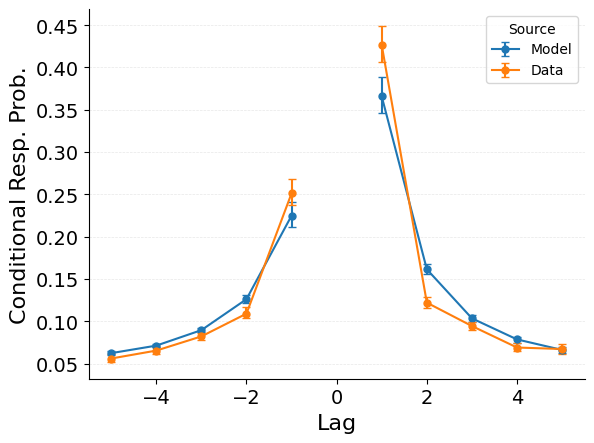

![](results/figures/HealeyKahana2014_WeirdCMRNoStop_fixed_term_best_of_3_pnr.png)


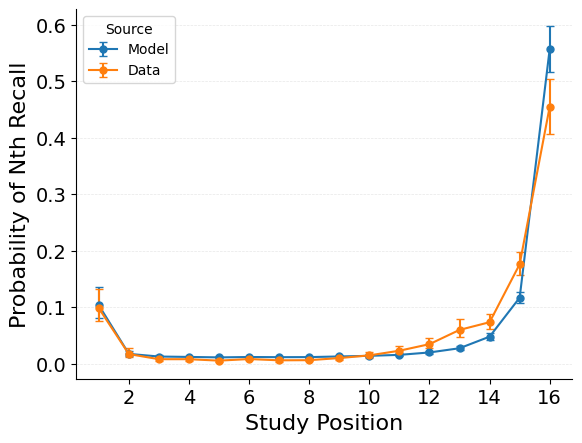

In [ ]:
# generate figures comparing model and data

for analysis in comparison_analyses:
    figure_str = f"{data_tag}_{model_name}_{run_tag}_{analysis.__name__[5:]}.png"
    figure_path = os.path.join(product_dirs["figures"], figure_str)
    print(f"![]({figure_path})")

    # if not redo_figures, check if figure already exists and don't redo
    # we want to display the figure here if it already exists
    if os.path.exists(figure_path) and not redo_figures:
        display(Image(filename=figure_path))
        continue

    color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]

    # Create a mask for data using np.isin for the selected list types
    trial_mask = generate_trial_mask(data, trial_query)
    sim_trial_mask = generate_trial_mask(sim, trial_query)

    axis = analysis(
        datasets=[sim, data],
        trial_masks=[sim_trial_mask, trial_mask],
        color_cycle=color_cycle,
        labels=["Model", "Data"],
        contrast_name="Source",
        axis=None,
        distances=distances,
    )

    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()